# AB Dor through `amigo-pipeline`

Runs AB Dor (program 1093) and its calibrators through Louis's `amigo-pipeline`, from calslopes to calibrated DISCOs, using the
`retrain` branches of both `amigo` and `amigo-pipeline`. The exposures and model are built here and handed to the pipeline's
Python interface, `Pipeline(exposures, model, ...)`, so every piece can be changed in this notebook.

The pipeline stages are: joint calibrator instrument fit (WFE, positions, fluxes, spectra, detector rotation) → science reference
fit with the instrument fixed → visibility-basis construction → joint-dither visibility fits → endpoint JTJ covariances and
calibration → nuisance nulling → DISCO reduction. `THROUGH` picks where to stop; completed stages are resumed from the output
directory, so it can be run a stage at a time.

- **Starting state:** `final_statev46.npy`, with static optics built from its fitted `transmission`, 28-mode Zernike aberrations,
  the trained ramp network and the per-pixel dark.
- **Data:** the full-covariance calslopes in `JWST/AB-DOR/calslope`, the same files `ab-dor_0.11.ipynb` uses.
- **Compute:** the stages compute exact-autodiff JTJ matrices and run BFGS, so use a GPU kernel for anything beyond a small test.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)
print(jax.local_devices()[0].device_kind)

import os
import sys
import json
import glob
import subprocess
from pathlib import Path

import numpy as onp
import jax.numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["font.size"] = 8

import amigo

# amigo-pipeline isn't installed in this environment: import it from its checkout
try:
    import amigo_pipeline
except ImportError:
    sys.path.insert(0, str(Path.home() / "code" / "amigo-pipeline" / "src"))
    import amigo_pipeline
from amigo_pipeline import Pipeline
from amigo_pipeline.pipeline import STAGES


def git_branch(module):
    root = Path(module.__file__).resolve().parents[2]
    return subprocess.run(["git", "-C", str(root), "branch", "--show-current"], capture_output=True, text=True).stdout.strip()


for module in (amigo, amigo_pipeline):
    print(f"{module.__name__:15s} {git_branch(module):10s} {Path(module.__file__).parent}")
assert git_branch(amigo) in ("retrain", "eigenbasis"), "check out amigo's retrain (or eigenbasis) branch"
assert git_branch(amigo_pipeline) == "retrain", "check out amigo-pipeline's retrain branch"

NVIDIA H200
amigo           retrain    /home/dgxuser/max/code/amigo/src/amigo
amigo_pipeline  retrain    /home/dgxuser/max/code/amigo-pipeline/src/amigo_pipeline


In [2]:
from socket import gethostname

if gethostname() in ("maxs-mbp-14.shared.sydney.edu.au", "Maxs-MacBook-Pro-14.local"):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs"
elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs"
else:
    data_dir = "/fred/oz440/max/data/JWST/"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs"

calslope_dir = os.path.join(data_dir, "AB-DOR/calslope/")

# ---- data ------------------------------------------------------------------
FILTERS = ["F480M"]  # any of F380M, F430M, F480M
SCIENCE = "AB-DOR"
CALIBRATORS = ["HD-37093"]  # and/or "HD-36805"
N_PER_STAR = 2  # calslopes per star per filter (in file order: visits, then dithers)

# ---- model -----------------------------------------------------------------
STATE_PATH = os.path.join(amigo_files_path, "final_statev46.npy")
# Starting aberrations, per filter; must match the optics' radial_orders (calibration.npy is 10 modes -> radial_orders=4).
# None uses STATE_PATH's own (28-mode) aberrations instead.
ABERRATIONS_PATH = os.path.join(amigo_files_path, "calibration.npy")

# ---- pipeline --------------------------------------------------------------
RUN_ROOT = Path(output_path) / "ab-dor_pipeline"  # stage reports, states and DISCOs go here
VISIBILITY_INFORMATION = 0.99  # information retained by the visibility basis
DISCO_INFORMATION = 0.99  # information retained by the DISCO reduction
DETECTOR_WIDTH_MAS = 2600.0
FOV_FRACTION = 0.75
PSF_PADDING_ENVELOPE_RADII = 1.0
FIT_DETECTOR_ROTATION = True
THROUGH = "instrument"  # stop after this stage; one of STAGES
RESUME = True  # reuse compatible completed stages already in RUN_ROOT
print("stages:", STAGES)

stages: ('instrument', 'science_reference', 'visibility_basis', 'visibility_fits', 'endpoint_jtj', 'calibrated_visibility', 'discos')


## 1. Exposures
Full UTR covariance and joint-dither coordinates (`use_cov=True, joint_fit=True`), which the pipeline requires.

These calslopes store `SLOPE_COV` as float32, so it is asymmetric at the float32 rounding level (~1e-8 relative). The pipeline
requires symmetry to 2e-10 (it expects the float64 products of its own preprocessing) and symmetrises right after that check
anyway, so the covariances are symmetrised here. The proper fix is re-making the calslopes with `amigo_pipeline.preprocess_dataset`.

In [3]:
import importlib
from astropy.io import fits
from amigo.model_fits import SplineVisFit

headers = []
for path in sorted(glob.glob(os.path.join(calslope_dir, "*_calslope.fits"))):
    h = fits.getheader(path)
    headers.append({"path": path, "star": h["TARGPROP"], "filter": h["FILTER"], "ngroups": h["NGROUPS"], "nints": h["NINTS"], "dither": h["PATT_NUM"]})


def pick(star, filt):
    return [h for h in headers if h["star"] == star and h["filter"] == filt][:N_PER_STAR]


selected = [h for filt in FILTERS for star in [SCIENCE, *CALIBRATORS] for h in pick(star, filt)]

with importlib.resources.as_file(importlib.resources.files(amigo) / "data" / "badpix.npy") as path:
    badpix = onp.asarray(onp.load(path), bool)


def asymmetry(cov):
    return float(np.max(np.abs(cov - np.swapaxes(cov, 0, 1))) / np.max(np.abs(cov)))


handles, exposures = [], []
for h in selected:
    handle = fits.open(h["path"], memmap=True)  # keep the handles open: the exposures may hold memmapped arrays
    handles.append(handle)
    exp = SplineVisFit(handle, use_cov=True, joint_fit=True).add_badpix(badpix)
    before = asymmetry(exp.cov)
    exp = exp.set("cov", 0.5 * (exp.cov + np.swapaxes(exp.cov, 0, 1)))
    exposures.append(exp)
    print(f"{exp.key:22s} {h['star']:9s} {h['filter']}  calibrator={bool(exp.calibrator)!s:5s} ngroups {h['ngroups']:3d} "
          f"nints {h['nints']:4d} dither {h['dither']:2d}  SLOPE_COV asymmetry {before:.1e}")

01093_012_02_03_1      AB-DOR    F480M  calibrator=False ngroups   5 nints   69 dither  1  SLOPE_COV asymmetry 0.0e+00
01093_012_05_03_1      AB-DOR    F480M  calibrator=False ngroups  13 nints   29 dither  1  SLOPE_COV asymmetry 0.0e+00
01093_015_02_03_1      HD-37093  F480M  calibrator=True  ngroups  12 nints   61 dither  1  SLOPE_COV asymmetry 1.2e-08
01093_016_02_03_1      HD-37093  F480M  calibrator=True  ngroups  12 nints   61 dither  1  SLOPE_COV asymmetry 1.1e-08


## 2. Model
Built from the fitted state. `calibration_from_state` (in `amigo_pipeline.model_factory`) gives each filter a starting wavefront
from the state's `<program>_<filter>` entries and adds `amigo`'s packaged bad-pixel map; exposure groups the state already has
keep their own wavefront. The visibility model is a zero-coefficient placeholder that the pipeline replaces before fitting visibilities.

In [4]:
import dLux.utils as dlu
from amigo.core_models import AmigoModel
from amigo.detector_models import LinearDetector
from amigo.optical_models import AMIOptics
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel
from amigo.vis_models import LogVisModel
from amigo_pipeline.model_factory import calibration_from_state

state = onp.load(STATE_PATH, allow_pickle=True).item()
calibration = calibration_from_state(state)
if ABERRATIONS_PATH is not None:
    calibration["aberrations"] = onp.load(ABERRATIONS_PATH, allow_pickle=True).item()["aberrations"]

optics = AMIOptics(radial_orders=4, sparse=True)  # static optics; AmigoModel loads the state's fitted transmission into it

n_knots = 3  # zero-visibility placeholder: identity transfer at zero coefficients
n_half = (n_knots**2 - 1) // 2
placeholder_basis = {
    "otf_coords": onp.asarray(dlu.pixel_coords(n_knots, 2 * float(optics.diameter))),
    "eigen_vectors": {part: {f: onp.eye(n_half) for f in FILTERS} for part in ("log_amp", "phase")},
}

model = AmigoModel(
    exposures=exposures,
    optics=optics,
    detector=LinearDetector(),
    read=ReadModel(per_pixel_dark=True),
    ramp_model=NonLinearRamp(),
    vis_model=LogVisModel(placeholder_basis, n_basis=1),
    state=calibration,
)
# Exposure groups the state already has keep their own wavefront (only when starting from the state's aberrations)
restored = {} if ABERRATIONS_PATH is not None else {key: state["aberrations"][key] for key in model.aberrations if key in state["aberrations"]}
model = model.set("aberrations", dict(model.aberrations) | restored)

pm = model.optics.pupil_mask
n_modes = pm.abb_basis.shape[1]
bad = {key: onp.shape(value) for key, value in model.aberrations.items() if onp.shape(value)[-1] != n_modes}
assert not bad, f"aberrations {bad} don't match the {n_modes}-mode basis: set radial_orders to match"
print(f"{type(pm).__name__}, aberration basis {pm.abb_basis.shape}, transmission from state: {bool(onp.allclose(pm.transmission, state['transmission']))}")
for key, value in model.aberrations.items():
    print(f"aberrations[{key}] {onp.shape(value)}" + ("  (from the state)" if key in restored else f"  (filter default from {os.path.basename(ABERRATIONS_PATH or STATE_PATH)})"))

StaticApertureMask, aberration basis (7, 10, 180, 180), transmission from state: True
aberrations[01093_F480M] (7, 10)  (filter default from calibration.npy)


### Exact-autodiff operators
`install_exact_ad` swaps in derivative-safe versions of AMIGO's interpolation and PSF square root (forward results unchanged).
Its interpolation operators have to be prepared for the visibility-basis image sizes as well as the detector image.

In [5]:
from amigo_pipeline.exact_ad import install_exact_ad
from amigo_pipeline.model_factory import visibility_image_sizes

image_sizes = visibility_image_sizes(
    optics, FILTERS, detector_width_mas=DETECTOR_WIDTH_MAS, fov_fraction=FOV_FRACTION,
    psf_padding_envelope_radii=PSF_PADDING_ENVELOPE_RADII,
)
exact_ad = install_exact_ad(model, exposures[0], checkpoint=True, extra_image_sizes=image_sizes)
print("exact_ad installed; image operator sizes:", list(exact_ad["image_operator_shapes"]))

exact_ad installed; image operator sizes: ['240', '300']


In [6]:
from amigo.fitting import loss_fn

for exp in exposures:
    loss = loss_fn(model, exp)
    loss = float(loss[0] if isinstance(loss, tuple) else loss)
    print(f"{exp.key:22s} {exp.star:9s} {exp.filter}  calibrator={bool(exp.calibrator)!s:5s}  initial loss {loss:10.2f}")

01093_012_02_03_1      AB-DOR    F480M  calibrator=False  initial loss     876.75
01093_012_05_03_1      AB-DOR    F480M  calibrator=False  initial loss    2184.24
01093_015_02_03_1      HD-37093  F480M  calibrator=True   initial loss     765.34
01093_016_02_03_1      HD-37093  F480M  calibrator=True   initial loss     827.01


File 01093_012_02_03_1
Star AB-DOR
Filter F480M
nints 69
ngroups 5



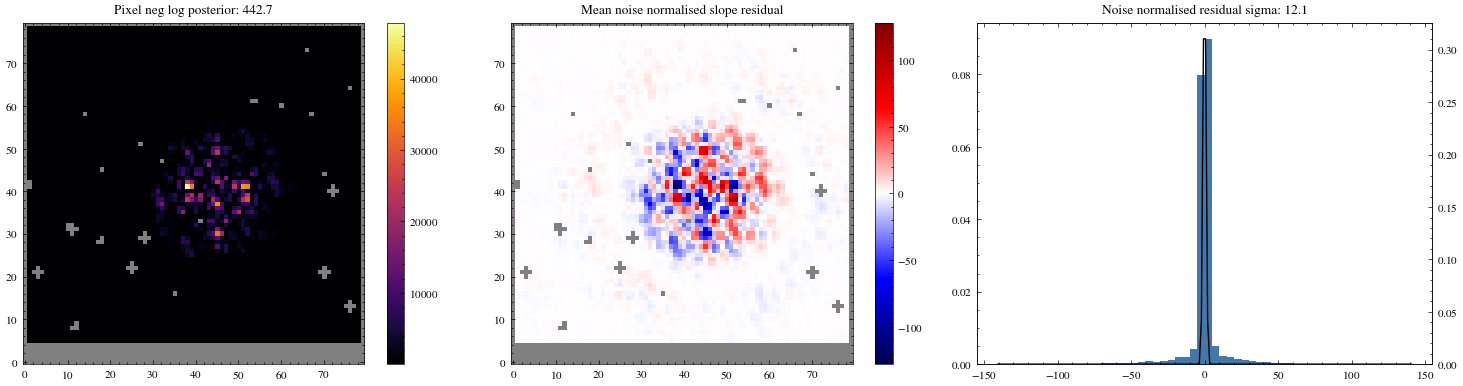

File 01093_012_05_03_1
Star AB-DOR
Filter F480M
nints 29
ngroups 13



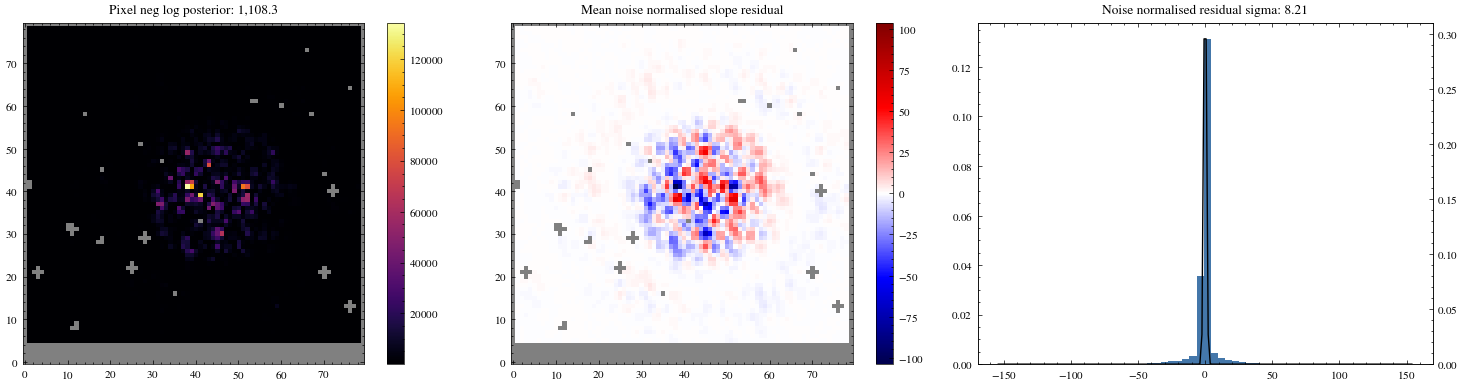

File 01093_015_02_03_1
Star HD-37093
Filter F480M
nints 61
ngroups 12



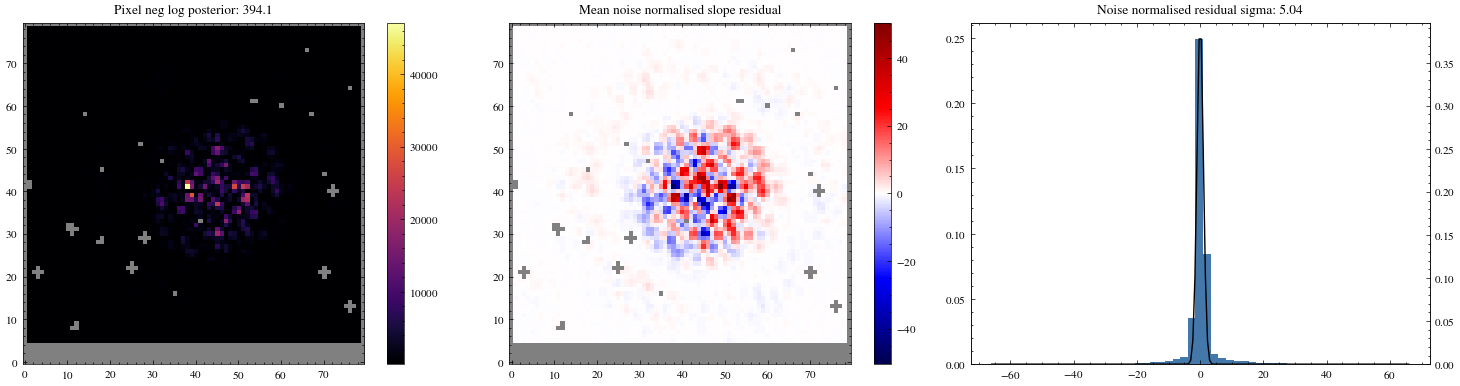

File 01093_016_02_03_1
Star HD-37093
Filter F480M
nints 61
ngroups 12



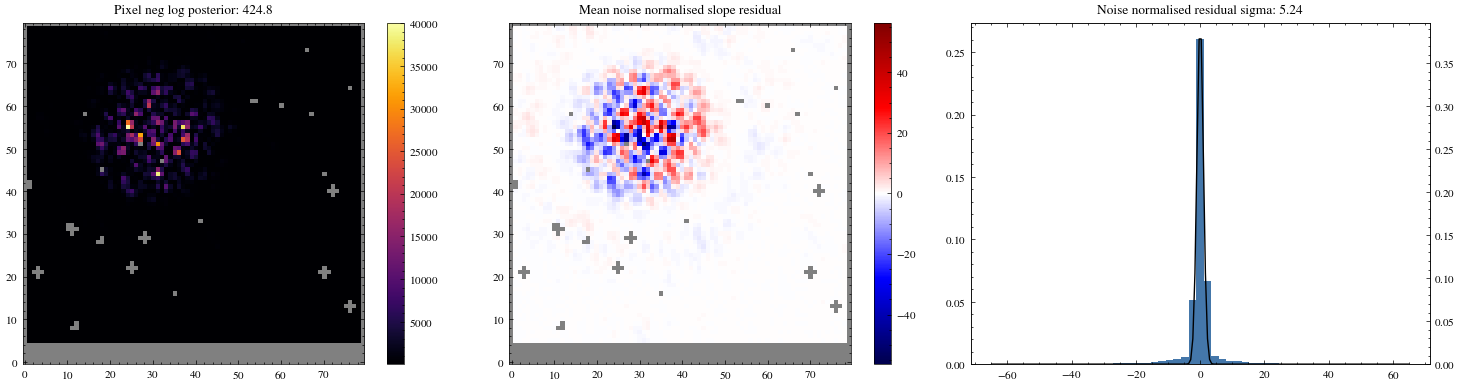

In [7]:
from amigo.plotting import summarise_fit

for exp in exposures:
    exp.print_summary()
    summarise_fit(model, exp, residuals=False, top_group=False)

## 3. Run the pipeline
Runs every stage up to and including `THROUGH`. Stage reports, saved states and products go to `RUN_ROOT`; a failure is recorded
in its `run.json` before being re-raised. Re-running with a later `THROUGH` resumes from the completed stages.

In [8]:
pipeline = Pipeline(
    exposures,
    model,
    output=RUN_ROOT,
    visibility_information=VISIBILITY_INFORMATION,
    disco_information=DISCO_INFORMATION,
    detector_width_mas=DETECTOR_WIDTH_MAS,
    fov_fraction=FOV_FRACTION,
    fit_detector_rotation=FIT_DETECTOR_ROTATION,
    null_ranks=("full",),
)
pipeline.exact_ad = exact_ad  # recorded in run.json for provenance

# A stage that misses the convergence policy raises; its result is still kept in pipeline.fit_results for inspection below.
try:
    result = pipeline.run(through=THROUGH, resume=RESUME)
    print("completed through", THROUGH)
except RuntimeError as error:
    result = None
    print("stopped:", error)
print("fit results kept:", list(pipeline.fit_results))

completed through instrument
fit results kept: ['instrument']


## 4. Instrument fit
The calibrator fit from the `instrument` stage, whether or not it met the convergence policy. The policy accepts a fit when the
Fisher-normalised gradient falls below its tolerance, or when the step size and loss change plateau; only parameter directions
whose JTJ eigenvalue is above `optimizer_rank_rtol` × the largest are optimised, the rest are held fixed as unidentified.

accepted: True (gradient)
loss: 4.55014e+06 -> 3.24715e+06
normalised gradient: 0.000206 (tolerance 0.000625)
parameters: 75 native, 11 optimised, 64 held fixed as unidentified (eigenvalues below 80.4; largest 8.04e+09)
BFGS pass 1: 0 iterations, 1 evaluations: Optimization terminated successfully.


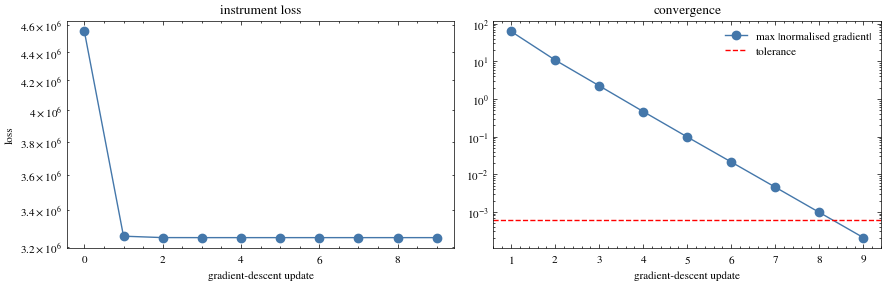

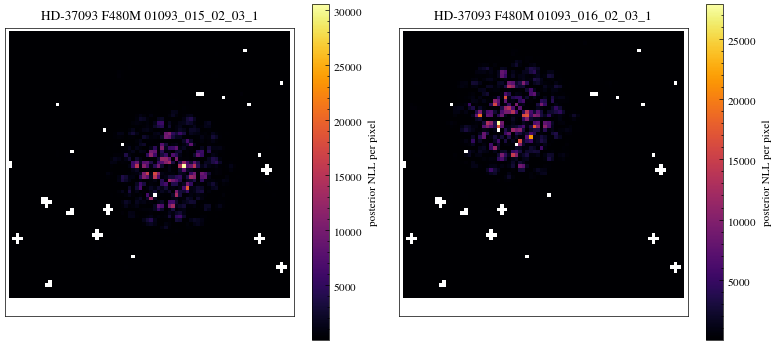

detector rotation: 0.56127 -> 0.56127


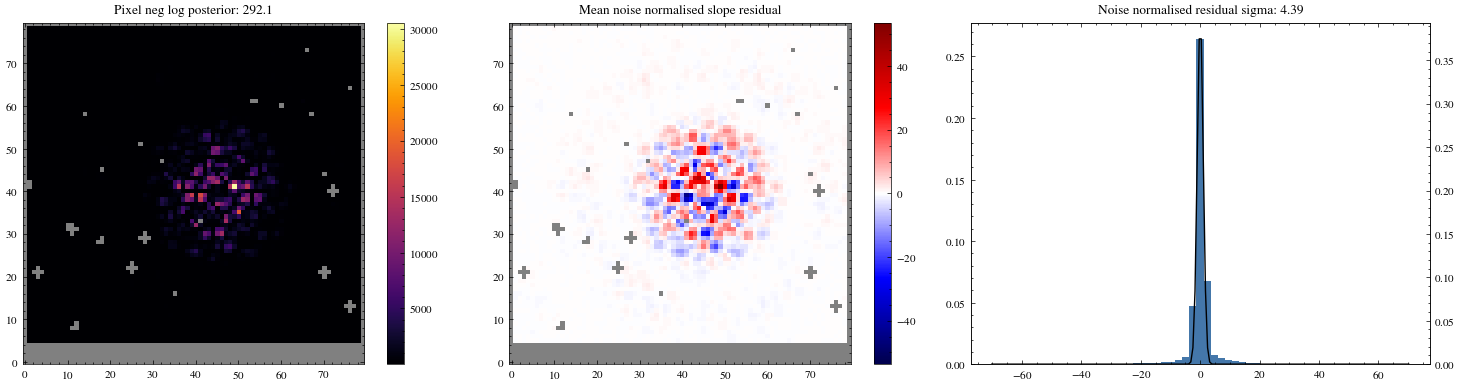

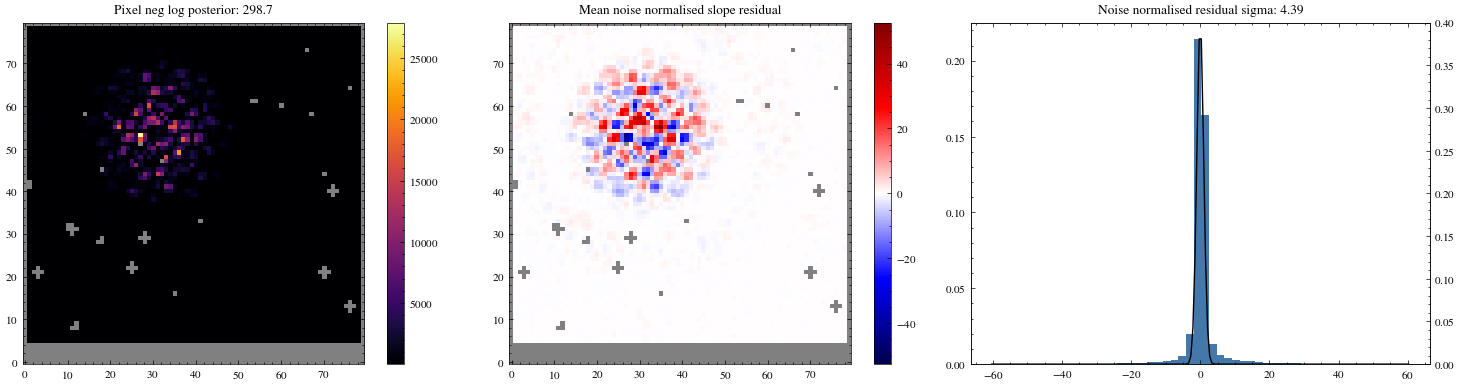

In [9]:
from amigo_pipeline import pixel_residual_diagnostics

report = json.loads((RUN_ROOT / "reports" / "instrument" / "report.json").read_text())
conv, pre, gd = report["convergence"], report["preconditioner"], report["optimizer"]["gradient_descent"]
bfgs = report["optimizer"].get("bfgs", {})
print(f"accepted: {report['accepted']} ({conv['reason']})")
print(f"loss: {report['initial_loss']:.6g} -> {report['final_loss']:.6g}")
print(f"normalised gradient: {bfgs.get('final_gradient_max_abs', gd[-1]['gradient_max_abs']):.3g} (tolerance {conv['gradient_tolerance']:.3g})")
print(f"parameters: {pre['native_dimension']} native, {pre['optimization_dimension']} optimised, "
      f"{pre['discarded_unidentified_dimension']} held fixed as unidentified (eigenvalues below {pre['rank_cutoff']:.3g}; "
      f"largest {pre['maximum_eigenvalue']:.3g})")
for p in bfgs.get("passes", []):
    print(f"BFGS pass {p['pass']}: {p['iterations']} iterations, {p['evaluations']} evaluations: {p['message']}")

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
steps = [s["update"] for s in gd]
ax[0].semilogy([0] + steps, [report["initial_loss"]] + [s["loss"] for s in gd], "o-")
ax[0].set(xlabel="gradient-descent update", ylabel="loss", title="instrument loss")
ax[1].semilogy(steps, [s["gradient_max_abs"] for s in gd], "o-", label="max |normalised gradient|")
ax[1].axhline(conv["gradient_tolerance"], color="r", ls="--", label="tolerance")
ax[1].set(xlabel="gradient-descent update", title="convergence")
ax[1].legend()
plt.tight_layout()
plt.show()

# The fitted model: in memory if this kernel ran the stage, otherwise the saved (accepted) state
if "instrument" in pipeline.fit_results:
    instrument_model = pipeline.fit_results["instrument"].model
else:
    instrument_model = pipeline.load_detector_model("instrument")

calibrators = tuple(e for e in exposures if e.calibrator)
diagnostics = pixel_residual_diagnostics(instrument_model, calibrators)
fig, ax = plt.subplots(1, len(diagnostics), figsize=(4 * len(diagnostics), 3.6), squeeze=False)
for a, exp, diag in zip(ax[0], calibrators, diagnostics):
    im = a.imshow(diag.image(diag.posterior_nll))
    a.set(title=f"{exp.star} {exp.filter} {exp.key}", xticks=[], yticks=[])
    fig.colorbar(im, ax=a, label="posterior NLL per pixel")
plt.tight_layout()
plt.show()

print(f"detector rotation: {float(model.get(pipeline.rotation_path)):.5f} -> {float(instrument_model.get(pipeline.rotation_path)):.5f}")
for exp in calibrators:
    summarise_fit(instrument_model, exp, top_group=False)

## 5. DISCOs
Only once `THROUGH = "discos"` has completed: the reduced, calibrated DISCO products, loaded into AMIGO's OI likelihood interface.

In [10]:
if STAGES.index(THROUGH) >= STAGES.index("discos"):
    from amigo_pipeline import load_oi_data

    disco_path = RUN_ROOT / "discos" / "null_full" / "discos.npy"
    oi = load_oi_data(disco_path)
    for name, data in oi.items():
        print(name, type(data).__name__)
else:
    print(f"THROUGH = {THROUGH!r}: DISCOs not produced yet")

THROUGH = 'instrument': DISCOs not produced yet
